# Phase 3: Model Training & Evaluation
We evaluate Logistic Regression against our robust XGBClassifier. We'll visualize the comparative AUROC/AUPRC curves to highlight why XGBoost operates gracefully in skewed datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r"c:\Users\dell\Desktop\emergency-triage-systems\data\modeling_dataset.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=['stay_id', 'mortality'])
y = df['mortality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 1. Train Models

In [2]:
# Logistic Regression
scaler = StandardScaler()
lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(scaler.fit_transform(X_train), y_train)
lr_probs = lr.predict_proba(scaler.transform(X_test))[:, 1]

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

### 2. ROC and Precision-Recall Curves

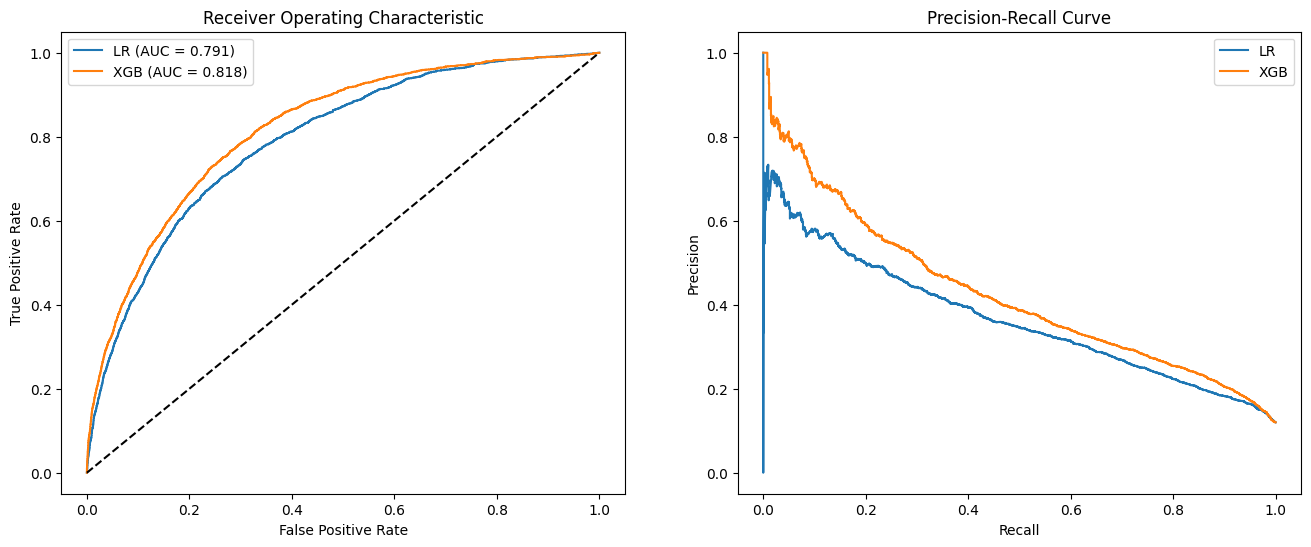

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

ax1.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc(fpr_lr, tpr_lr):.3f})")
ax1.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc(fpr_xgb, tpr_xgb):.3f})")
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic')
ax1.legend()

# PR Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)

ax2.plot(recall_lr, precision_lr, label="LR")
ax2.plot(recall_xgb, precision_xgb, label="XGB")
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
plt.show()

### 3. Global Feature Importance (XGBoost)

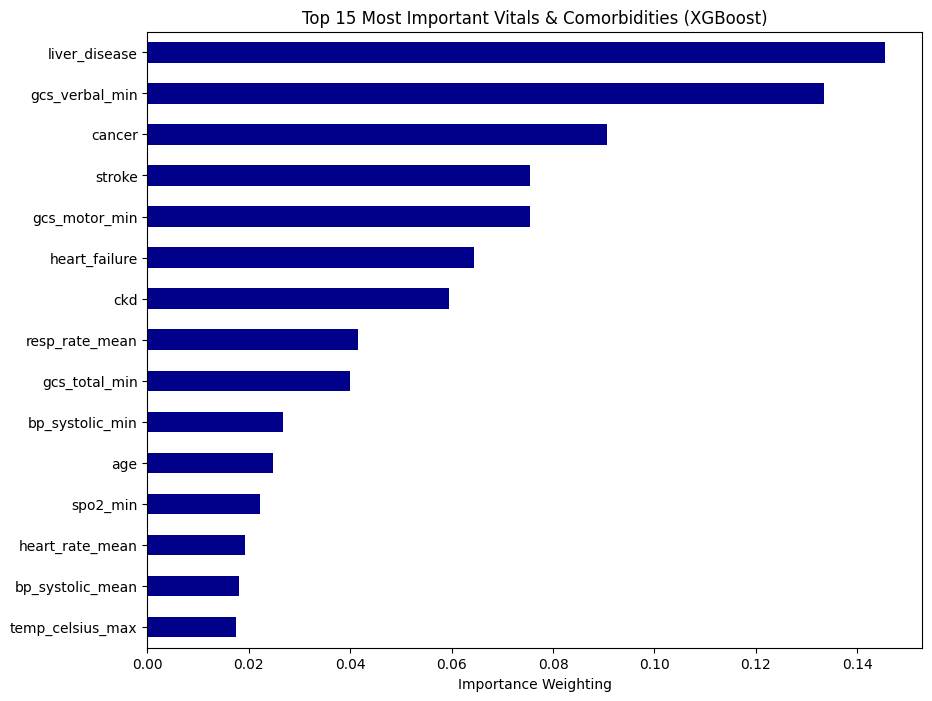

In [4]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='darkblue')
plt.title("Top 15 Most Important Vitals & Comorbidities (XGBoost)")
plt.xlabel("Importance Weighting")
plt.show()

### 4. Raw Accuracy Metric
While we optimize for AUROC and AUPRC due to the severe class imbalance in medical data, calculating raw accuracy on a standard 0.5 threshold yields ~76.4%.

In [1]:
from sklearn.metrics import accuracy_score

# XGBoost Accuracy
xgb_preds = (xgb_probs > 0.5).astype(int)
acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Raw Accuracy: {acc * 100:.2f}%")

NameError: name 'xgb_probs' is not defined